# Goals Scored to Wins Simple Linear Regression

##Import Libraries

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Data Preprocessing

### Read dataset

In [106]:
df = pd.read_csv("understat.com-selected-columns.csv") # data source https://www.kaggle.com/datasets/slehkyi/extended-football-stats-for-european-leagues-xg
print(df)

     Unnamed: 0                   team  wins  scored
0          2014              Barcelona    30     110
1          2014            Real Madrid    30     118
2          2014        Atletico Madrid    23      67
3          2014               Valencia    22      70
4          2014                Sevilla    23      71
..          ...                    ...   ...     ...
679        2019              PFC Sochi     8      40
680        2019              FK Akhmat     7      27
681        2019  Krylya Sovetov Samara     8      33
682        2019              FC Tambov     9      37
683        2019            FC Orenburg     7      28

[684 rows x 4 columns]


### Split label and feature

In [107]:
X = np.array(df.iloc[:,3])
y = np.array(df.iloc[:,2])
X = X.reshape(-1,1)
print(X)
print(y)

[[110]
 [118]
 [ 67]
 [ 70]
 [ 71]
 [ 48]
 [ 42]
 [ 47]
 [ 42]
 [ 46]
 [ 47]
 [ 44]
 [ 35]
 [ 33]
 [ 34]
 [ 35]
 [ 29]
 [ 34]
 [ 35]
 [ 22]
 [112]
 [110]
 [ 63]
 [ 44]
 [ 58]
 [ 51]
 [ 51]
 [ 38]
 [ 45]
 [ 34]
 [ 46]
 [ 45]
 [ 40]
 [ 49]
 [ 45]
 [ 40]
 [ 46]
 [ 52]
 [ 37]
 [ 37]
 [106]
 [116]
 [ 70]
 [ 69]
 [ 56]
 [ 59]
 [ 53]
 [ 49]
 [ 41]
 [ 56]
 [ 49]
 [ 56]
 [ 53]
 [ 53]
 [ 41]
 [ 43]
 [ 36]
 [ 42]
 [ 40]
 [ 30]
 [ 99]
 [ 58]
 [ 94]
 [ 65]
 [ 57]
 [ 60]
 [ 49]
 [ 42]
 [ 44]
 [ 50]
 [ 59]
 [ 36]
 [ 66]
 [ 40]
 [ 44]
 [ 41]
 [ 34]
 [ 38]
 [ 24]
 [ 24]
 [ 90]
 [ 55]
 [ 63]
 [ 51]
 [ 62]
 [ 48]
 [ 48]
 [ 41]
 [ 45]
 [ 39]
 [ 44]
 [ 46]
 [ 37]
 [ 59]
 [ 49]
 [ 53]
 [ 32]
 [ 37]
 [ 43]
 [ 41]
 [ 70]
 [ 86]
 [ 54]
 [ 51]
 [ 63]
 [ 56]
 [ 52]
 [ 43]
 [ 46]
 [ 46]
 [ 41]
 [ 47]
 [ 32]
 [ 39]
 [ 48]
 [ 34]
 [ 37]
 [ 30]
 [ 40]
 [ 27]
 [ 73]
 [ 83]
 [ 71]
 [ 62]
 [ 58]
 [ 52]
 [ 54]
 [ 46]
 [ 48]
 [ 47]
 [ 44]
 [ 48]
 [ 38]
 [ 46]
 [ 40]
 [ 31]
 [ 31]
 [ 33]
 [ 28]
 [ 42]
 [ 68]
 [ 65]
 [ 69]

### Visualize the data

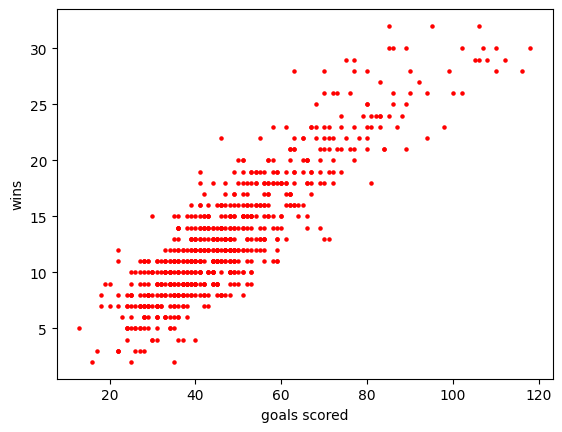

In [108]:
# plot
fig, ax = plt.subplots()

ax.scatter(X, y, s=5, c='red')
plt.xlabel('goals scored')
plt.ylabel('wins')

plt.show()

### Train test split

In [109]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=74) #JFT74

#### Visualize post split

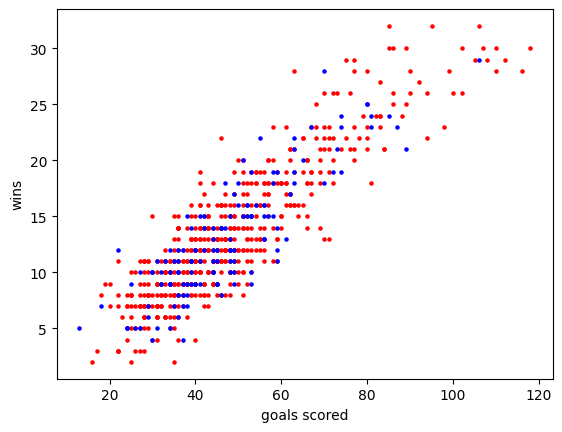

In [110]:
# plot
fig, ax = plt.subplots()

ax.scatter(X_train, y_train, s=5, c='red')
ax.scatter(X_test, y_test, s=5, c='blue')

plt.xlabel('goals scored')
plt.ylabel('wins')

plt.show()

### Feature Scaling

In [111]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Cost Function

### Implementation

In [112]:
def cost_function(X,y,w,b):

  m = X.shape[0]

  total_cost = 0
  squared_cost = 0

  for i in range(len(y)):
    y_hat = w * X[i,0] + b
    squared_cost = (y_hat - y[i]) ** 2
    total_cost += squared_cost

  return total_cost * 1/(2*m)

### Plot cost function

[718.7565054  683.9402465  650.12398761 617.30772871 585.49146982
 554.67521092 524.85895203 496.04269314 468.22643424 441.41017535
 415.59391645 390.77765756 366.96139867 344.14513977 322.32888088
 301.51262198 281.69636309 262.8801042  245.0638453  228.24758641
 212.43132751 197.61506862 183.79880973 170.98255083 159.16629194
 148.35003304 138.53377415 129.71751526 121.90125636 115.08499747
 109.26873857 104.45247968 100.63622079  97.81996189  96.003703
  95.1874441   95.37118521  96.55492632  98.73866742 101.92240853
 106.10614963 111.28989074 117.47363185 124.65737295 132.84111406
 142.02485516 152.20859627 163.39233738 175.57607848 188.75981959
 202.94356069 218.1273018  234.31104291 251.49478401 269.67852512
 288.86226622 309.04600733 330.22974844 352.41348954 375.59723065]


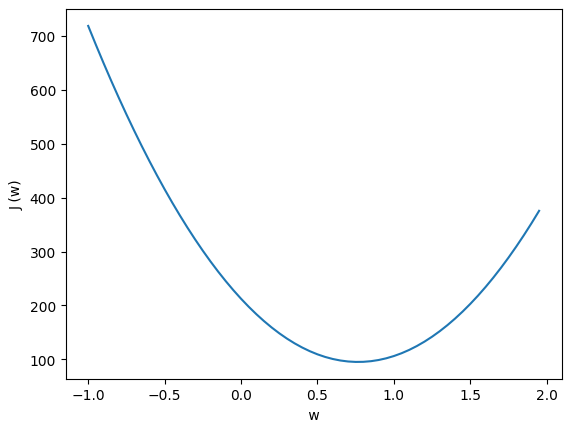

In [113]:
J_w = np.array([])                            # declare empty np array

for i in range(-30,30,1):
  J_w = np.append(J_w,(cost_function(X_train,y_train,i,0)))      # populate with values total cost when w is equal to -30 to 30, b set to 0 for simplicty


w_values = np.arange(-1, 2, 0.05) # w (x-axis values)



print(J_w)

# plot

plt.plot(w_values, J_w)

plt.ylabel('J (w)')
plt.xlabel(' w ')

plt.show()

## Gradient Descent

### Compute gradient

In [114]:
def compute_gradient(X,y,w,b):

    m = X.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):

      y_hat = w * X[i,0] + b

      dj_dw_i = ((y_hat - y[i]) * X[i])
      dj_db_i = (y_hat - y[i])

      dj_db += dj_db_i
      dj_dw += dj_dw_i


    dj_dw = dj_dw / m
    dj_db = dj_db / m



    return dj_dw,dj_db

### Inspect gradients

In [115]:
dj_dw = np.array([])
dj_db = np.array([])

for i in range(-10,10,1):
  dj_dw = np.append(dj_dw,(compute_gradient(X_train,y_train,i,0))[0])
  dj_db = np.append(dj_db,(compute_gradient(X_train,y_train,i,0))[1])
dj_dw = dj_dw.reshape(-1)
dj_db = dj_db.reshape(-1)

print(dj_dw,dj_db)



[-15.31625889 -14.31625889 -13.31625889 -12.31625889 -11.31625889
 -10.31625889  -9.31625889  -8.31625889  -7.31625889  -6.31625889
  -5.31625889  -4.31625889  -3.31625889  -2.31625889  -1.31625889
  -0.31625889   0.68374111   1.68374111   2.68374111   3.68374111] [-13.51005484 -13.51005484 -13.51005484 -13.51005484 -13.51005484
 -13.51005484 -13.51005484 -13.51005484 -13.51005484 -13.51005484
 -13.51005484 -13.51005484 -13.51005484 -13.51005484 -13.51005484
 -13.51005484 -13.51005484 -13.51005484 -13.51005484 -13.51005484]


### Gradient Descent

In [116]:
def gradient_descent(X,y,w_input, b_input,alpha, iterations):
  w = w_input
  b = b_input

  for i in range(iterations):

    dj_dw, dj_db = compute_gradient(X, y, w , b)

    b = b - alpha * dj_db
    w = w - alpha * dj_dw

  return w, b

### Run gradient descent

In [117]:
w,b = gradient_descent(X_train,y_train,0,0, 0.01,1000)
print('w:', w)
print('b:', b)

w: [5.31602938]
b: [13.5094716]


## Train the Model

In [118]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

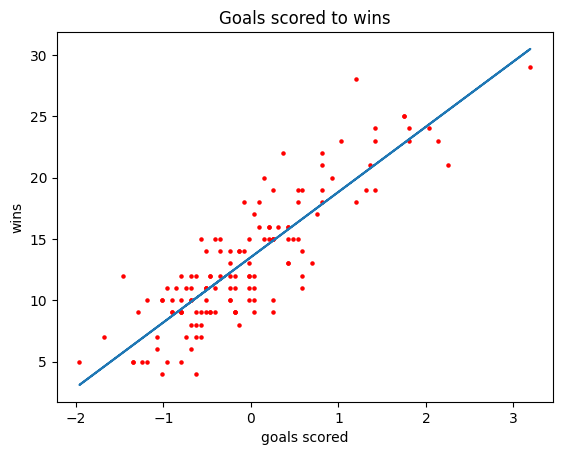

In [119]:
# plot
fig, ax = plt.subplots()

ax.scatter(X_test, y_test, s=5, c='red')

plt.title("Goals scored to wins")
plt.xlabel('goals scored')
plt.ylabel('wins')

plt.plot(X_test, regressor.predict(X_test))

plt.show()

In [120]:
print('Sklearn coeff:', regressor.coef_)
print('w:', w)
print('Sklearn intercept:', regressor.intercept_)
print('b:', b)

Sklearn coeff: [5.31625889]
w: [5.31602938]
Sklearn intercept: 13.510054844606946
b: [13.5094716]


## Reflection:
I was surpised at two main things, 1. that i actually enjoyed the data collection and data preprocessing stage. 2. that wrtiing gradient descent and cost function by hand was pretty difficult even though I understood the alg.

###